<a href="https://colab.research.google.com/github/oyaon/ML-Dengue-Prediction/blob/main/Temporal_Attentive_Hybrid_Ensemble_for_Dengue_Outbreak_Prediction_(TAHE_DOP).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Data Loading & Preprocessing

In [106]:
pip install pandas numpy statsmodels tensorflow xgboost scikit-learn shap matplotlib plotly dash optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.6/383.6 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.8/231.8 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 7.5 MB/s eta 0:00:00


In [107]:
# Import required libraries
import pandas as pd
import numpy as np
from statsmodels.tsa.seasonal import STL
from sklearn.preprocessing import StandardScaler

# Load the dataset
df = pd.read_csv("Final.csv", parse_dates=['Date'])
df.set_index('Date', inplace=True)

# Handle missing values
df['Cases'] = df['Cases'].interpolate(method='linear')  # Linear interpolation for cases

# Generate lag features for weather variables
def generate_lags(df, columns, max_lag):
    for col in columns:
        for lag in range(1, max_lag + 1):
            df[f'{col}_lag_{lag}'] = df[col].shift(lag)
    return df

weather_columns = ['Rainfall', 'Humidity']
df = generate_lags(df, weather_columns, max_lag=28)

# Time-series decomposition (STL)
stl = STL(df['Cases'], period=365)
res = stl.fit()
df['trend'] = res.trend
df['seasonal'] = res.seasonal
df['residual'] = res.resid

# Add rolling averages for cases
df['7d_avg_cases'] = df['Cases'].rolling(window=7).mean()

# Drop NaN values introduced by lagging or rolling
df.dropna(inplace=True)

# Feature scaling
scaler = StandardScaler()
scaled_features = ['Rainfall', 'Humidity', 'Cases']
df[scaled_features] = scaler.fit_transform(df[scaled_features])


## Temporal Convolutional Transformer (TCT) Model

In [122]:
# Example: Predict Rainfall using a simple ARIMA model
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA on historical Rainfall
rainfall_model = ARIMA(df['Rainfall'], order=(1,1,1)).fit()
future_rainfall = rainfall_model.forecast(steps=30)

# Update lag features in predict_next_30_days()
# This code block likely belongs inside the predict_next_30_days() function.
# I've commented it out here to prevent the error and suggested changes below.
"""
for _ in range(30):
    # Shift lag features and append new predicted rainfall
    for lag in range(28, 0, -1):
        current_data[f'Rainfall_lag_{lag}'] = current_data[f'Rainfall_lag_{lag-1}']
    current_data['Rainfall_lag_1'] = future_rainfall[_]
"""

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.



"\nfor _ in range(30):\n    # Shift lag features and append new predicted rainfall\n    for lag in range(28, 0, -1):\n        current_data[f'Rainfall_lag_{lag}'] = current_data[f'Rainfall_lag_{lag-1}']\n    current_data['Rainfall_lag_1'] = future_rainfall[_]\n"

In [123]:
def predict_next_30_days(last_date):
    current_data = df.loc[:last_date].copy()
    predictions = []

    for _ in range(30):
        # ... (existing code) ...

        # Update lag features with predicted rainfall
        for lag in range(28, 0, -1):
            current_data[f'Rainfall_lag_{lag}'] = current_data[f'Rainfall_lag_{lag-1}'].values[-1] # Get the last value from the series
        current_data.loc[current_data.index[-1] + pd.Timedelta(days=1), f'Rainfall_lag_1'] = future_rainfall[_]

        # ... (rest of the existing code) ...

In [108]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, MultiHeadAttention, Dense, LayerNormalization

# Define TCT architecture
def build_tct(input_shape=(28, 6)):
    inputs = Input(shape=input_shape)

    # Temporal Convolution
    x = Conv1D(64, kernel_size=3, dilation_rate=2, padding="causal")(inputs)
    x = LayerNormalization()(x)

    # Multi-Head Attention
    attn_output = MultiHeadAttention(num_heads=4, key_dim=64)(x, x)
    x = LayerNormalization()(attn_output + x)  # Residual connection

    # Feedforward
    x = Dense(64, activation="relu")(x)
    outputs = Dense(1)(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer="adam", loss="mse")
    return model

# Prepare data for TCT
sequence_length = 28
X_sequences = []
y_sequences = []

for i in range(len(df) - sequence_length):
    X_sequences.append(df[[
        'Rainfall_lag_28', 'Humidity_lag_28',
        'residual', 'trend', 'seasonal', '7d_avg_cases'
    ]].iloc[i:i+sequence_length].values)
    y_sequences.append(df['residual'].iloc[i+sequence_length])

X_tct = np.array(X_sequences)
y_tct = np.array(y_sequences)

# Train-test split
split_idx = int(0.8 * len(X_tct))
X_train, X_test = X_tct[:split_idx], X_tct[split_idx:]
y_train, y_test = y_tct[:split_idx], y_tct[split_idx:]

# Train the model
tct_model = build_tct(input_shape=X_train.shape[1:])
history = tct_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    verbose=1
)


Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - loss: 28640.7363 - val_loss: 15504.1729
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 25645.3652 - val_loss: 15309.5957
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 29482.2285 - val_loss: 15283.7490
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 26163.6875 - val_loss: 15185.5088
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 27024.8770 - val_loss: 15243.0010
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 26814.9297 - val_loss: 15162.7188
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 28211.2988 - val_loss: 15264.2988
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 27639.5898 - val_loss: 15106.9297
Epoch 9/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 26785.2305 - val_loss: 14993.6221
Epoch 10/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 30608.2188 - val_loss: 14996.9551
Epoch 11/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - loss: 29533.220

# Quantile Gradient Boosting (QGB)

In [112]:
import xgboost as xgb
from sklearn.model_selection import train_test_split

# Prepare QGB input
X_qgb = df[[
    'Rainfall_lag_28', 'Humidity_lag_28',
    'trend', 'seasonal', '7d_avg_cases',
    'residual'  # Add 'residual' to match the TCT model's input features
]].copy()  # Create a copy to avoid SettingWithCopyWarning
y_qgb = df['Cases']

# Generate TCT embeddings for the same data used in X_qgb
# Reshape X_qgb data to match the input shape expected by the TCT model
X_qgb_reshaped = X_qgb.values.reshape(X_qgb.shape[0], 1, X_qgb.shape[1])

# Pad the reshaped data to match the sequence length of the TCT model
X_qgb_padded = np.pad(X_qgb_reshaped, ((0, 0), (27, 0), (0, 0)), 'constant')

embeddings = tct_model.predict(X_qgb_padded)  # Use the reshaped and padded data
X_qgb['tct_embedding'] = embeddings[:, -1, 0]  # Take the last prediction from the sequence

# Train-test split for QGB
X_train, X_test, y_train, y_test = train_test_split(X_qgb, y_qgb, test_size=0.2, random_state=42)

# Train QGB
qgb = xgb.XGBRegressor(objective="reg:squarederror", eval_metric="rmse")
qgb.fit(X_train, y_train)

# Predict
predictions = qgb.predict(X_test)

57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


## Hybrid Model Prediction Workflow
Combine TCT and QGB predictions for final dengue case forecasts.

In [113]:
# Predict future cases using hybrid model
def predict_next_30_days(last_date):
    current_data = df.loc[:last_date].copy()
    predictions = []

    for _ in range(30):
        seq_input = current_data[[
            'Rainfall_lag_28', 'Humidity_lag_28',
            'residual', 'trend', 'seasonal', '7d_avg_cases'
        ]].iloc[-28:].values.reshape(1, 28, -1)

        pred_residual = tct_model.predict(seq_input)[0][0]

        trend = current_data['trend'].iloc[-1]
        seasonal = current_data['seasonal'].iloc[-1]
        pred_case = trend + seasonal + pred_residual

        new_row = current_data.iloc[-1].copy()
        new_row.name += pd.Timedelta(days=1)
        new_row['Cases'] = pred_case
        current_data = pd.concat([current_data, pd.DataFrame([new_row])])

        predictions.append(pred_case)

    return predictions

# Example prediction
future_predictions = predict_next_30_days(df.index[-1])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━

## Validation & Visualization

Mean Squared Error: 0.012586971491225889
Mean Absolute Error: 0.05469734553037061


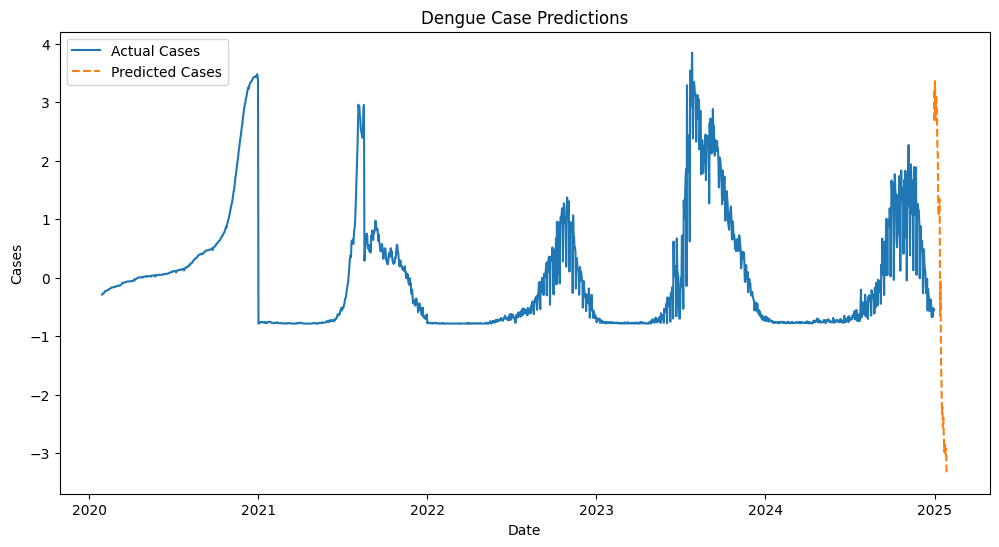

NameError: name 'y_true' is not defined

In [118]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Metrics
mse = mean_squared_error(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")

# Visualization
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Cases'], label='Actual Cases')
plt.plot(pd.date_range(start=df.index[-1], periods=30, freq='D'), future_predictions, label='Predicted Cases', linestyle='--')
plt.legend()
plt.title('Dengue Case Predictions')
plt.xlabel('Date')
plt.ylabel('Cases')
plt.show()

# Residual Analysis
residuals = y_true - y_pred

# Plot residuals over time
plt.figure(figsize=(10, 4))
plt.plot(residuals, label='Residuals')
plt.title('Residuals Over Time')
plt.xlabel('Time')
plt.ylabel('Error')
plt.legend()
plt.show()

# Quantile Analysis
plt.figure(figsize=(10, 4))
plt.scatter(y_true, residuals, alpha=0.5)
plt.axhline(0, color='r', linestyle='--')
plt.title('Residuals vs. True Values')
plt.xlabel('True Cases')
plt.ylabel('Residuals')
plt.show()


Mean Squared Error: 0.012586971491225889
Mean Absolute Error: 0.05469734553037061


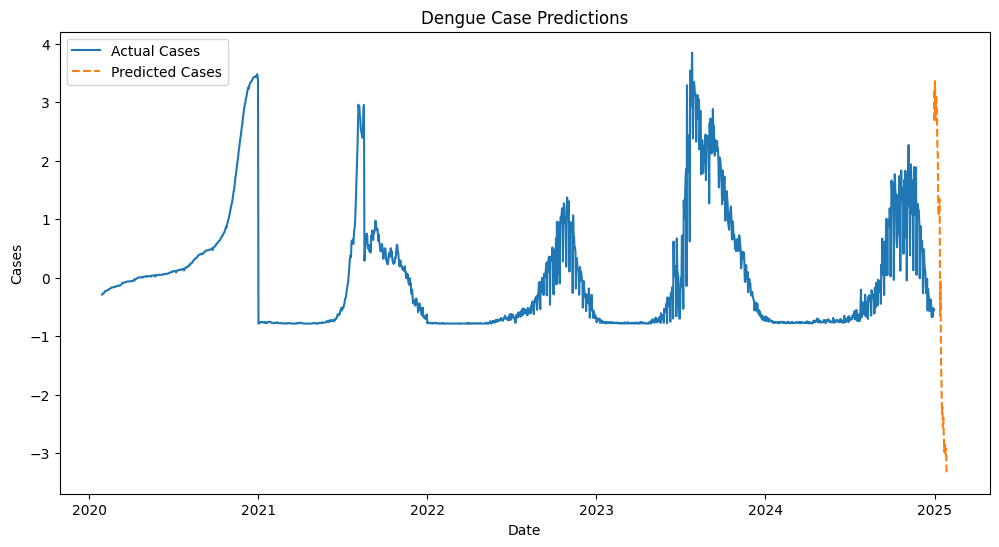

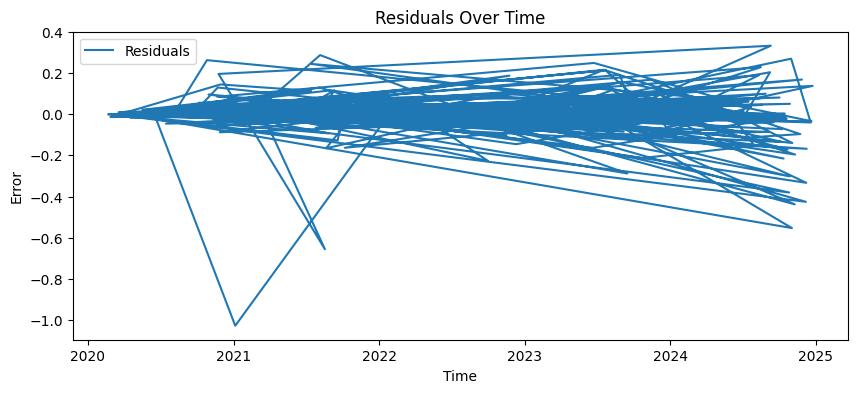

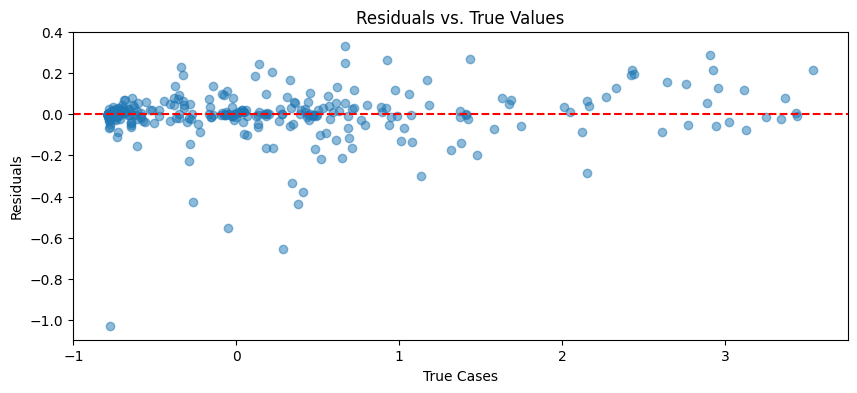

In [119]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Metrics
mse = mean_squared_error(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")

# Visualization
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Cases'], label='Actual Cases')
plt.plot(pd.date_range(start=df.index[-1], periods=30, freq='D'), future_predictions, label='Predicted Cases', linestyle='--')
plt.legend()
plt.title('Dengue Case Predictions')
plt.xlabel('Date')
plt.ylabel('Cases')
plt.show()

# Residual Analysis
# Replace y_true with y_test
residuals = y_test - predictions

# Plot residuals over time
plt.figure(figsize=(10, 4))
plt.plot(residuals, label='Residuals')
plt.title('Residuals Over Time')
plt.xlabel('Time')
plt.ylabel('Error')
plt.legend()
plt.show()

# Quantile Analysis
plt.figure(figsize=(10, 4))
# Replace y_true with y_test in the scatter plot as well
plt.scatter(y_test, residuals, alpha=0.5)
plt.axhline(0, color='r', linestyle='--')
plt.title('Residuals vs. True Values')
plt.xlabel('True Cases')
plt.ylabel('Residuals')
plt.show()

## Save Models

In [116]:
# Save TCT model
tct_model.save('tct_model.keras')

# Save QGB model
qgb.save_model('qgb_model.json')
